Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load continuous wrist flexion data from Delsys Galileo sensor

In [2]:
df = pd.read_csv("galileo_data.csv", header=0)
df.columns = ["ch_1_time", "ch_1_voltage", 
              "ch_2_time", "ch_2_voltage", 
              "ch_3_time", "ch_3_voltage", 
              "ch_4_time", "ch_4_voltage"]

Define function to compute FFT for multiple EMG channels

In [3]:
# Inputs: Array of time (s) values, array of voltage (mV) values
# Outputs: Array of frequency (Hz) values, array of amplitude (mV) values

def compute_fft(channel_time, channel_voltage):

    # Define axes
    time = channel_time.to_numpy()
    voltage = channel_voltage.to_numpy()

    # Sampling information
    dt = np.mean(np.diff(time))   # Interval in seconds (mean time between samples)
    N = len(voltage)              # Number of samples

    # Subtract mean to remove DC offset (spike at 0 Hz)
    voltage = voltage - np.mean(voltage)

    # FFT
    fft_amplitude = np.fft.fft(voltage)
    fft_freq = np.fft.fftfreq(N, d=dt)

    # Keep only positive frequencies
    freqs = fft_freq[fft_freq >= 0]

    # Take absolute value to remove phase information and divide by the number of samples since the FFT is a sum over N samples
    amplitude = np.abs(fft_amplitude[fft_freq >= 0]) / N

    return freqs, amplitude

Plot FFT outputs

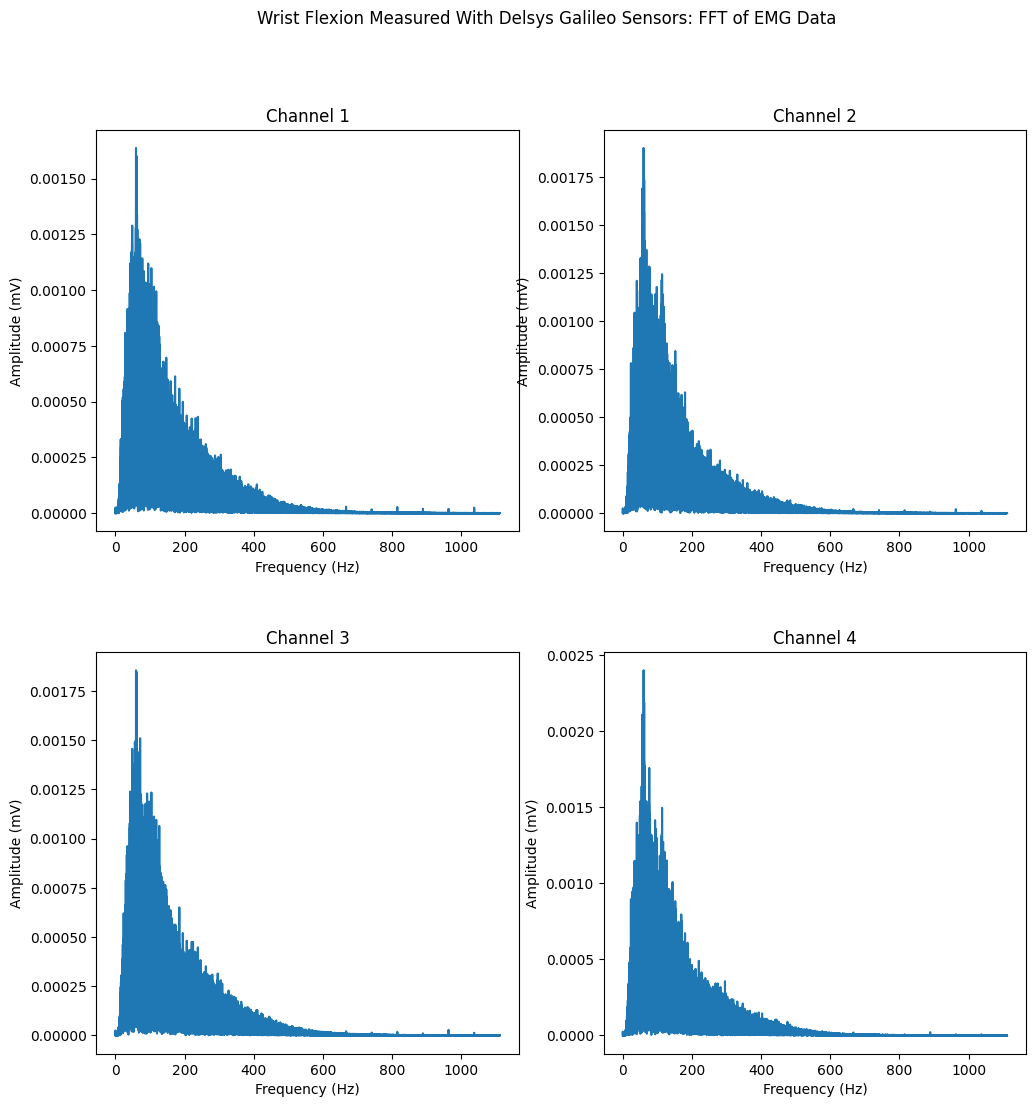

In [4]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle("Wrist Flexion Measured With Delsys Galileo Sensors: FFT of EMG Data")
fig.subplots_adjust(hspace=0.3)

freqs_1, amp_1 = compute_fft(df["ch_1_time"], df["ch_1_voltage"])
ax1.plot(freqs_1, amp_1)
ax1.set_title("Channel 1")
ax1.set_xlabel("Frequency (Hz)")
ax1.set_ylabel("Amplitude (mV)")

freqs_2, amp_2 = compute_fft(df["ch_2_time"], df["ch_2_voltage"])
ax2.plot(freqs_2, amp_2)
ax2.set_title("Channel 2")
ax2.set_xlabel("Frequency (Hz)")
ax2.set_ylabel("Amplitude (mV)")

freqs_3, amp_3 = compute_fft(df["ch_3_time"], df["ch_3_voltage"])
ax3.plot(freqs_3, amp_3)
ax3.set_title("Channel 3")
ax3.set_xlabel("Frequency (Hz)")
ax3.set_ylabel("Amplitude (mV)")

freqs_4, amp_4 = compute_fft(df["ch_4_time"], df["ch_4_voltage"])
ax4.plot(freqs_4, amp_4)
ax4.set_title("Channel 4")
ax4.set_xlabel("Frequency (Hz)")
ax4.set_ylabel("Amplitude (mV)")

plt.show()